In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Dataset_Study3.csv")
#df.head()
y = df['Label']
df.drop('Label',axis =1,inplace =True)

In [80]:
#Standard scaler data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(data_scaled,columns=df.columns)

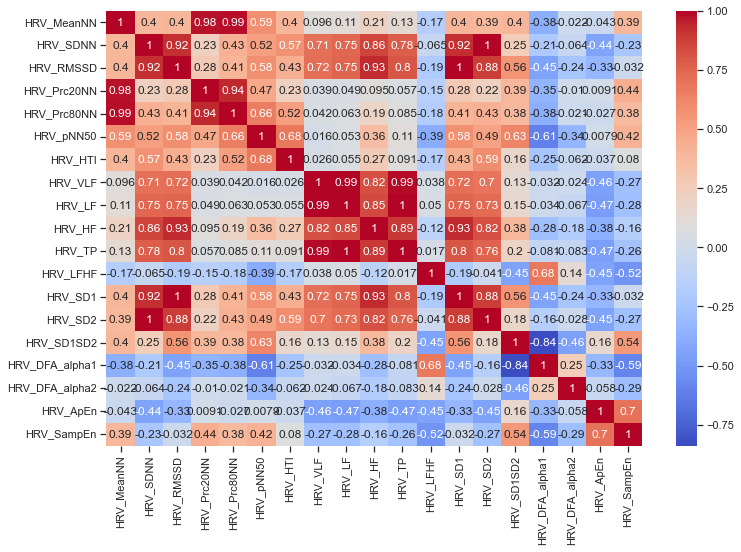

In [141]:
corr_matrix = X_scaled.corr()
plt.figure(figsize =(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',)
plt.show()

# ANova


In [143]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# Assuming X_scaled is your feature matrix and y is your target variable

# Create SelectKBest object
bestfeatures = SelectKBest(score_func=f_classif, k=5)

# Fit the object to your data
fit = bestfeatures.fit(X_scaled, y)

# Get scores for each feature
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X_scaled.columns)

# Concatenate the dataframes to get a summary dataframe
feature_scores = pd.concat([dfcolumns, dfscores], axis=1)
feature_scores.columns = ['Feature', 'Score']

# Sort the features by score in descending order
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Get the top k features
top_features = feature_scores.head(5)['Feature'].tolist()

# Create a new dataframe with the selected features
X_selected = X_scaled[top_features]

# spilt data
from sklearn.model_selection import train_test_split
X_train, x_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2)



In [146]:
from sklearn import svm
from sklearn.metrics import accuracy_score

In [147]:

# Create an SVM classifier with a linear kernel (you can choose other kernels as needed)
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr' stands for One-vs-Rest

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.38372093023255816


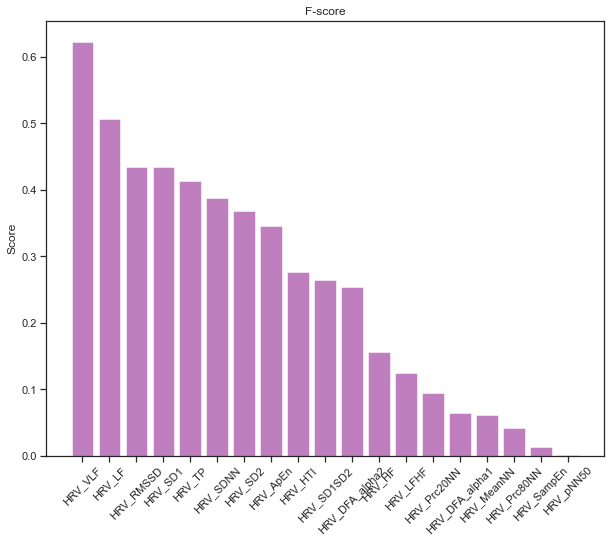

In [68]:
# Concatenate two dataframes for better visualization 
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Feature', 'Score']
featureScores = featureScores.sort_values(by='Score',ascending=False)

plt.figure(figsize=(10,8))
plt.bar(featureScores['Feature'], featureScores['Score'], color='purple',alpha=0.5)
plt.title('F-score')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

# rfe + logisctic regression

In [148]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
rfe = RFE(model, n_features_to_select=5) # Selecting top 5 features
fit = rfe.fit(X_scaled, y)
# Print the selected features
selected_features = [f for f, s in zip(df.columns, fit.support_) if s]
print("Selected Features: ", selected_features)
X_rfe = X_scaled[selected_features]
X_rfe
X_train, x_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2)


Selected Features:  ['HRV_RMSSD', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_TP']


In [149]:

# Create an SVM classifier with a linear kernel (you can choose other kernels as needed)
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr' stands for One-vs-Rest

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.313953488372093


# Random forest

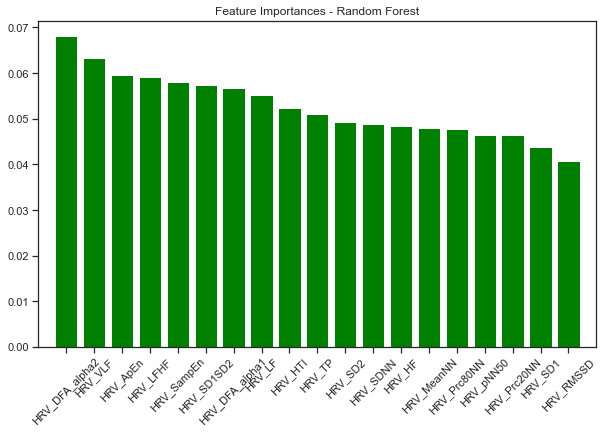

In [124]:

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_scaled, y)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plotting feature importances
plt.figure(figsize=(10,6))
plt.title('Feature Importances - Random Forest')
plt.bar(range(df.shape[1]), importances[indices], color='green', align='center')
plt.xticks(range(df.shape[1]), df.columns[indices], rotation=45)
plt.xlim([-1, df.shape[1]])
plt.show()


In [150]:
columns = ['HRV_DFA_alpha2','HRV_VLF','HRV_DFA_alpha2','HRV_SD1SD2','HRV_LFHF','HRV_HTI']
X_fi = X_scaled[columns]
X_train, x_test, y_train, y_test = train_test_split(X_fi, y, test_size=0.2)

#X_fi

In [151]:

# Create an SVM classifier with a linear kernel (you can choose other kernels as needed)
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr' stands for One-vs-Rest

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.27906976744186046


In [152]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS
# Forward Selection using SFS from sklearn
sfs_forward = SFS(estimator=model,
                  n_features_to_select=5,
                  direction='forward',
                  scoring='accuracy',
                  cv=5)
sfs_forward = sfs_forward.fit(X_scaled, y)
cols = df.columns[sfs_forward.get_support()==True]
X_sfs  =  X_scaled[cols]
X_train, x_test, y_train, y_test = train_test_split(X_sfs, y, test_size=0.2)


In [153]:

# Create an SVM classifier with a linear kernel (you can choose other kernels as needed)
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr' stands for One-vs-Rest

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.26744186046511625


In [154]:
# Backward Elimination using SFS from sklearn
sfs_backward = SFS(estimator=model,
                   n_features_to_select=5, 
                   direction='backward',
                   scoring='accuracy',
                   cv=5)
sfs_backward = sfs_backward.fit(X_scaled, y)
cols = df.columns[sfs_backward.get_support()==True]
X_sfs_b  =  X_scaled[cols]
X_train, x_test, y_train, y_test = train_test_split(X_sfs_b, y, test_size=0.2)


In [155]:

# Create an SVM classifier with a linear kernel (you can choose other kernels as needed)
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr' stands for One-vs-Rest

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.2558139534883721


In [131]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

scaler = StandardScaler()

# LASSO Regression with cross-validation
lasso = LassoCV(cv=5, random_state=0)
lasso_pipeline = Pipeline([('scaler', scaler), ('lasso', lasso)])
lasso_pipeline.fit(X_scaled, y)
lasso_coef = lasso.coef_
lasso_features = [feature for feature, coef in zip(df.columns, lasso_coef) if coef != 0]
print("Lasso picked " + str(sum(lasso_coef != 0)) + " variables and eliminated the other " +  str(sum(lasso_coef == 0)) + " variables")
print("The selected features are:",lasso_features)
X_lasso = X_scaled[lasso_features]
X_train, x_test, y_train, y_test = train_test_split(X_lasso, y, test_size=0.2)


C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 23035.262995855883, tolerance: 562.1612738235295
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 87097.8849452408, tolerance: 562.1612738235295
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarni

Lasso picked 0 variables and eliminated the other 19 variables
The selected features are: []


C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 847.3190694423392, tolerance: 566.9513190615837
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 981.7133654570207, tolerance: 566.9513190615837
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarni

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

# Assuming X_scaled is your feature matrix and y is your target variable

# RandomForestClassifier for feature importance
rf_model = RandomForestClassifier()
rf_model.fit(X_scaled, y)

# Extracting feature importances
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

# DecisionTreeClassifier for feature importance
dtree_model = DecisionTreeClassifier(random_state=0)
dtree_model.fit(X_scaled, y)

# Extracting feature importances
dtree_importances = dtree_model.feature_importances_
dtree_indices = np.argsort(dtree_importances)[::-1]

# Select top 7 features from both models
top_features_rf = X_scaled.columns[rf_indices[:7]]
top_features_dtree = X_scaled.columns[dtree_indices[:7]]

# Create dataframes with feature importances
rf_feature_importances_df = pd.DataFrame({
    'Feature': top_features_rf,
    'RF_Importance': rf_importances[rf_indices[:7]]
})

dtree_feature_importances_df = pd.DataFrame({
    'Feature': top_features_dtree,
    'DTree_Importance': dtree_importances[dtree_indices[:7]]
})

# Merge the dataframes on the 'Feature' column
combined_feature_importances_df = pd.merge(rf_feature_importances_df, dtree_feature_importances_df, on='Feature')

# Display the combined dataframe
print(combined_feature_importances_df)

x_dtree = X_scaled[top_features_dtree]
x_rf = X_scaled[top_features_rf]
X_train, x_test, y_train, y_test = train_test_split(x_dtree, y, test_size=0.2)
#X_train, x_test, y_train, y_test = train_test_split(x_rf, y, test_size=0.2)



          Feature  RF_Importance  DTree_Importance
0  HRV_DFA_alpha2       0.064654          0.112162
1  HRV_DFA_alpha1       0.060926          0.076639
2        HRV_LFHF       0.055956          0.080613
3         HRV_VLF       0.053967          0.076187


In [135]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, random_state=0)
selector_rf = SelectFromModel(random_forest)
selector_rf.fit(X_scaled, y)

selected_features_rf = df.columns[(selector_rf.get_support())]
selected_features_rf
X_rf2 = X_scaled[selected_features_rf]
X_train, x_test, y_train, y_test = train_test_split(X_rf2, y, test_size=0.2)


In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split


# Function to build model and evaluate
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, precision, recall



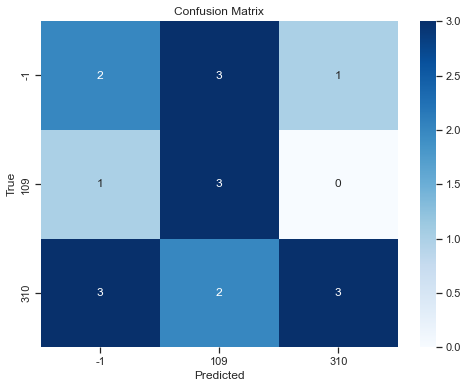

(0.4444444444444444, 0.4861111111111111, 0.4861111111111111)

In [121]:
#kbest
evaluate_model(x_test,y_test)

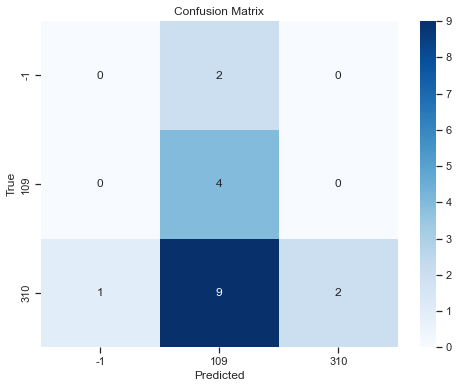

(0.3333333333333333, 0.4222222222222222, 0.3888888888888889)

In [123]:
#rfe
evaluate_model(x_test,y_test)

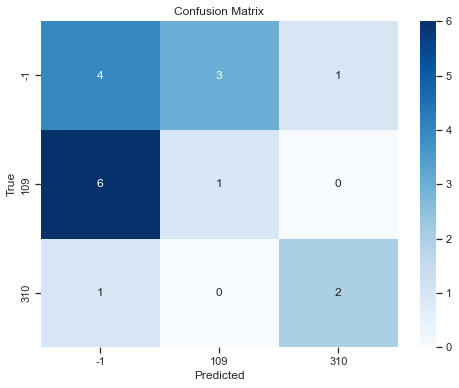

(0.3888888888888889, 0.42676767676767674, 0.43650793650793646)

In [126]:
#random forest
evaluate_model(x_test,y_test)

C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


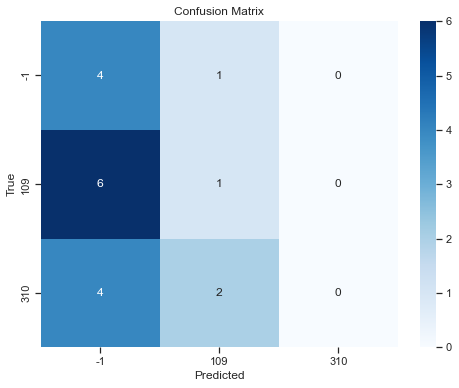

(0.2777777777777778, 0.17857142857142858, 0.3142857142857143)

In [128]:
#sfs forward
evaluate_model(x_test,y_test)

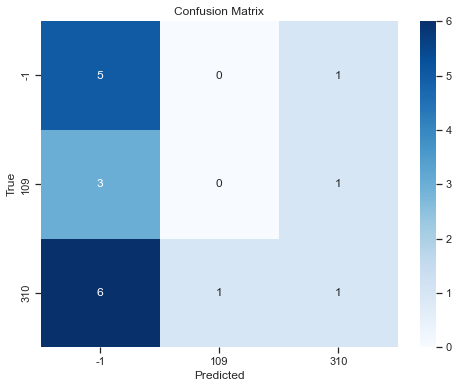

(0.3333333333333333, 0.23015873015873015, 0.3194444444444445)

In [130]:
#sfs backward
evaluate_model(x_test,y_test)

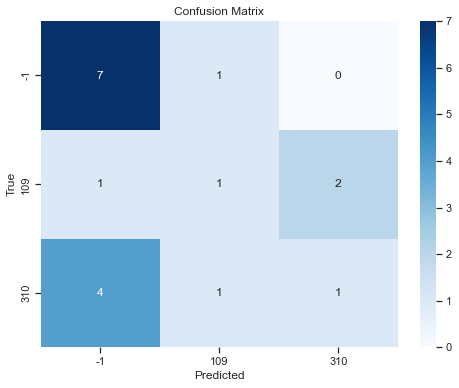

(0.5, 0.4166666666666667, 0.4305555555555556)

In [134]:
# dtree
evaluate_model(x_test,y_test)

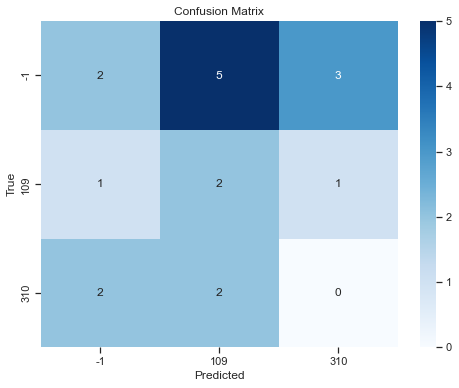

(0.2222222222222222, 0.2074074074074074, 0.2333333333333333)

In [136]:
#rf2
evaluate_model(x_test,y_test)

In [ ]:
from sklearn.linear_model import 
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split


# Function to build model and evaluate
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, precision, recall

